Tables created

 ROLAP Result:
   dept_id    avg_salary
0        1  93333.333333
1        2  77500.000000
2        3  60000.000000


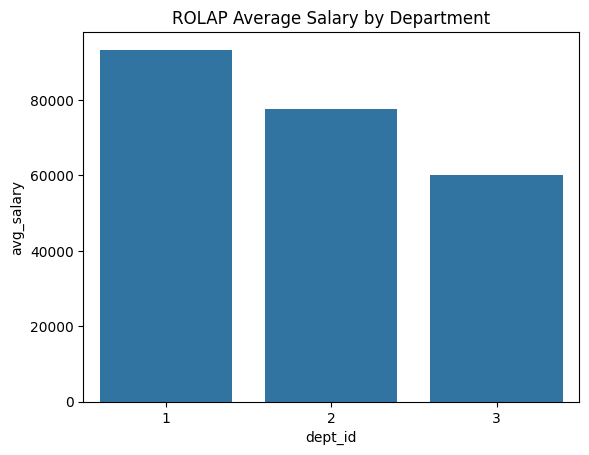

In [8]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

#database connection
def create_connection(db_file="olab_demo.db"):
    conn = sqlite3.connect(db_file)
    return conn

#dataset
employees = pd.DataFrame({
    'emp_id':[1,2,3,4,5,6],
    'name':["Alice",'Bob','Charlie','David','Eva ','Frank'],
    'age':[30,35,40,28,32,45],
    'salary':[70000,80000,120000,60000,75000,90000],
    'dept_id':[1,2,1,3,2,1]
})
departments=pd.DataFrame({
    'dept_id':[1,2,3],
    'dept_name':['HR','Engineering','Sales']

})

#load the dataset into sqlite
conn=create_connection()
employees.to_sql('employees',conn, if_exists='replace',index=False)
departments.to_sql('departments',conn, if_exists='replace',index=False)

print("Tables created")

#Perform OLAP operation
#ROLAP Operations

query="""
SELECT d.dept_id, AVG(e.salary) as avg_salary
FROM employees e
JOIN departments d ON e.dept_id = d.dept_id
GROUP BY d.dept_id

"""

rolap_result= pd. read_sql_query(query, conn)
print("\n ROLAP Result:")
print(rolap_result)

sns.barplot(data=rolap_result, x='dept_id',y='avg_salary')
plt.title("ROLAP Average Salary by Department")
plt.show()


C:\Users\midev\AppData\Local\Temp\ipykernel_16452\1325942605.py:2: FutureWarning: The provided callable <function mean at 0x00000234AD8787C0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  molap_cube=pd.pivot_table(



MOLAP Cube
age               28       30       32       35        40       45
dept_name                                                         
Engineering      0.0      0.0  75000.0  80000.0       0.0      0.0
HR               0.0  70000.0      0.0      0.0  120000.0  90000.0
Sales        60000.0      0.0      0.0      0.0       0.0      0.0


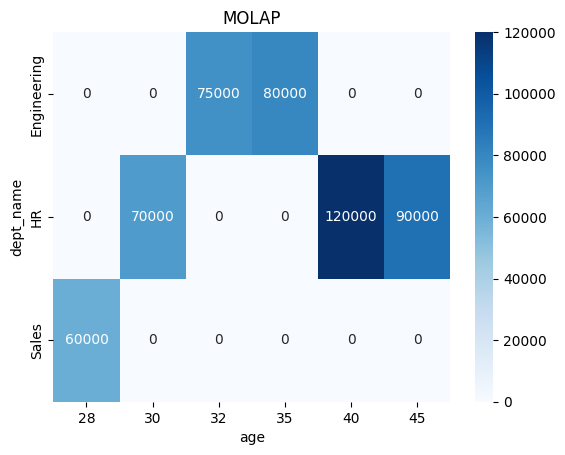

In [13]:
#
molap_cube=pd.pivot_table(
    employees.merge(departments, on='dept_id'),
    values='salary',
    index='dept_name',
    columns='age',
    aggfunc=np.mean,
    fill_value=0

)
print("\nMOLAP Cube")
print(molap_cube)

sns.heatmap(molap_cube,annot=True, fmt=".0f", cmap="Blues")
plt.title("MOLAP")
plt.show()


In [15]:
detail_sql="""
SELECT e.name, e.salary, d.dept_name
FROM employees e
JOIN departments d ON e.dept_id=d.dept_id
"""

detail_df=pd.read_sql_query(detail_sql, conn)

holap_summary= detail_df.groupby('dept_name')['salary'].mean().reset_index()

print("\n MOLAP Summary:")
print(holap_summary)


 MOLAP Summary:
     dept_name        salary
0  Engineering  77500.000000
1           HR  93333.333333
2        Sales  60000.000000


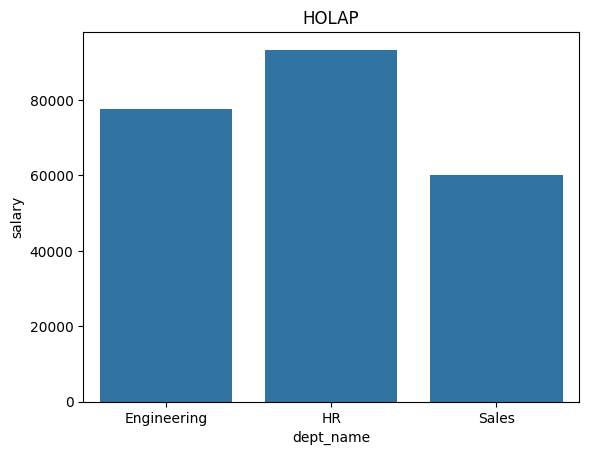

In [12]:
sns.barplot(x='dept_name', y='salary', data=holap_summary)
plt.title("HOLAP")
plt.show()

Inslice (IT Department) :
Empty DataFrame
Columns: [name, salary, dept_name]
Index: []

 Dice (HR Department with Salary > 60000):
      name  salary dept_name
0    Alice   70000        HR
2  Charlie  120000        HR
5    Frank   90000        HR


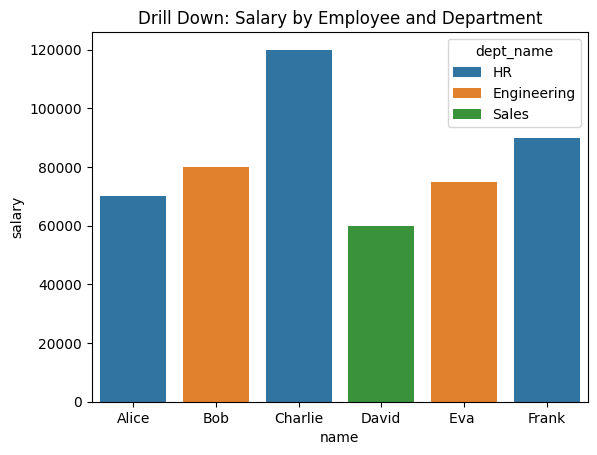


Ro11 Up (Total Salary by Department):
     dept_name  salary
0  Engineering  155000
1           HR  280000
2        Sales   60000


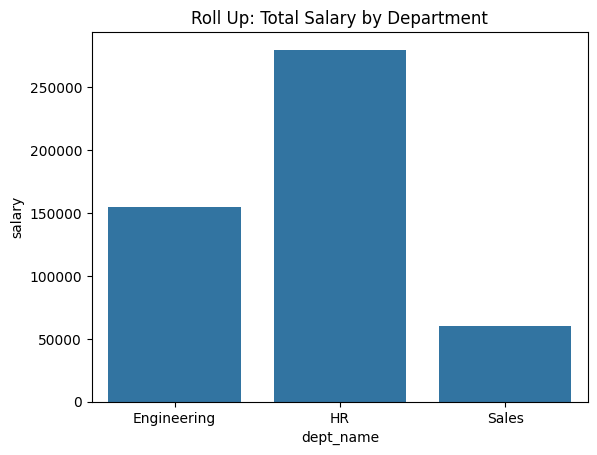

In [18]:
#slice 
slice_df=detail_df [detail_df['dept_name']=='IT'] 
print("Inslice (IT Department) :") 
print(slice_df) 

#dice 
dice_df=detail_df[(detail_df['dept_name']=='HR') & (detail_df['salary']>60000)] 
print("\n Dice (HR Department with Salary > 60000):") 
print(dice_df) 

#drill down 
sns.barplot (data=detail_df, x='name', y='salary', hue='dept_name') 
plt.title("Drill Down: Salary by Employee and Department") 
plt.show()
 
#rollup 
rollup_df=detail_df.groupby('dept_name')['salary'].sum().reset_index() 
print("\nRo11 Up (Total Salary by Department):") 
print(rollup_df) 

#visualization :rollup 
sns.barplot (data=rollup_df, x='dept_name', y='salary') 
plt. title("Roll Up: Total Salary by Department") 
plt. show()

#close the database connection
conn.close()
